# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Census Income dataset.
2. My label is income_binary and I am predicting whether an individual's annual income is greater than 50,000 or less than or equal to 50,000.
3. I plan to initially use: Age, Workclass, Education-num, Marital-status, Occupation, Relationship, Race, Sex_selfID, Capital-gain, Capital-loss, Hours-per-week, Native-country
4. EquiLend's goal is to develop a binary classification model that predicts whether an individual's annual income exceeds 50,000. By learning patterns from demographic and employment information in the Census dataset, the model can help EquiLend evaluate applications more efficiently. Accurate predictions could help prioritize applicants. The model can also identify individuals who may qualify for financial assistance or lending programs, and support more informed decision-making. This can increase efficiency and enable EquiLend to better serve their clients.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

0    24720
1     7841
Name: income_binary, dtype: int64


Text(0.5, 1.0, 'Class Distribution: income_binary')

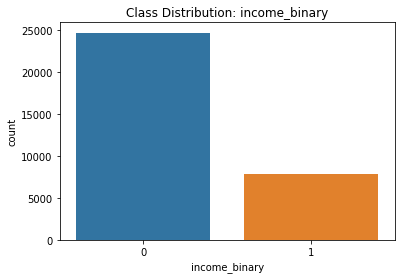

In [3]:
df['income_binary'] = df['income_binary'].map({'<=50K': 0, '>50K': 1})
print(df['income_binary'].value_counts())
sns.countplot(data=df, x="income_binary")
plt.title('Class Distribution: income_binary')

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

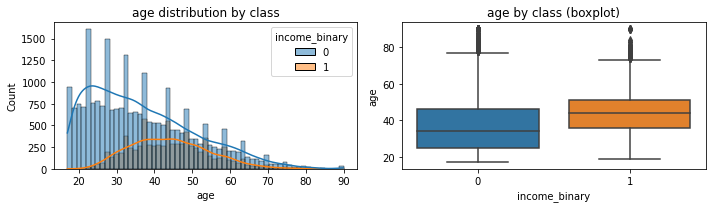

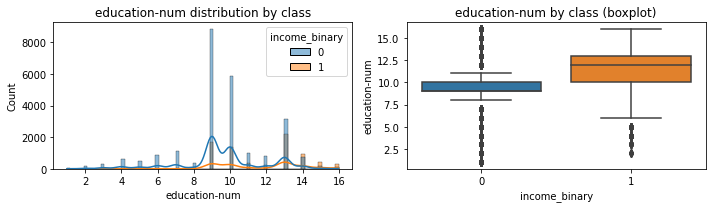

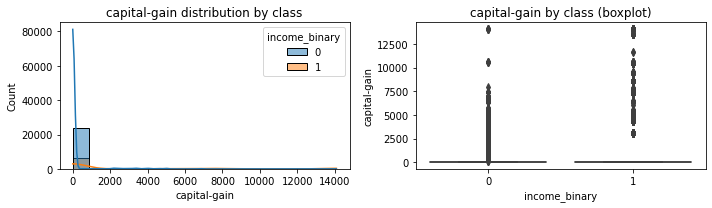

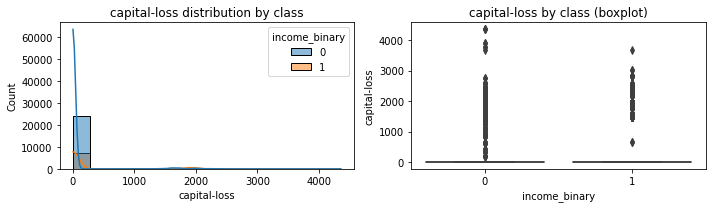

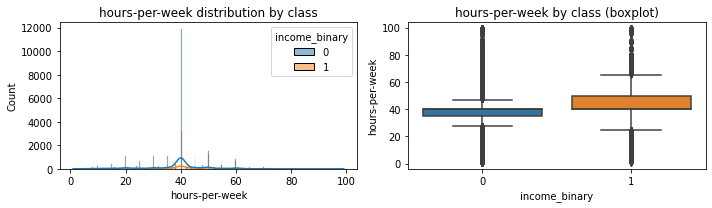

In [4]:
numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(data=df, x=col, hue='income_binary', kde=True, ax=axes[0])
    axes[0].set_title(f'{col} distribution by class')
    sns.boxplot(data=df, x='income_binary', y=col, ax=axes[1])
    axes[1].set_title(f'{col} by class (boxplot)')
    plt.tight_layout()
    plt.show()

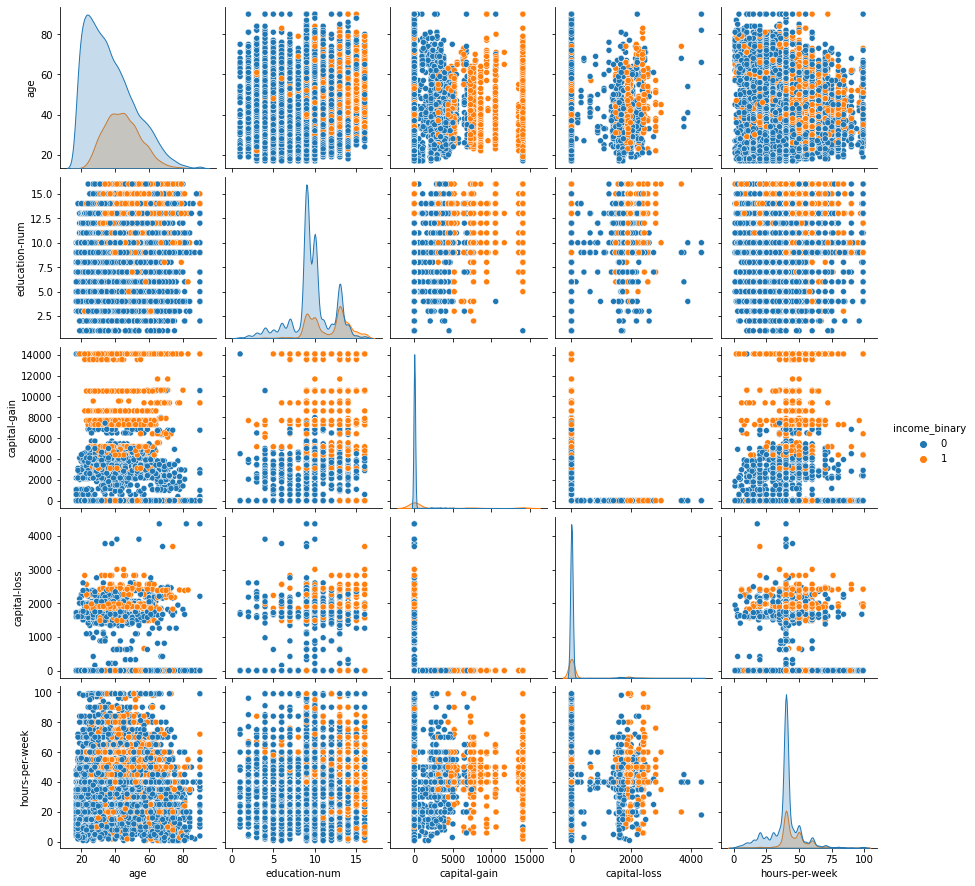

In [5]:
sns.pairplot(df[numeric_features + ['income_binary']], hue='income_binary')
plt.show()

workclass
                  proportion_over_50k  count
Federal-gov                  0.386458    960
Local-gov                    0.294792   2093
Never-worked                 0.000000      7
Private                      0.218673  22696
Self-emp-inc                 0.557348   1116
Self-emp-not-inc             0.284927   2541
State-gov                    0.271957   1298
Without-pay                  0.000000     14


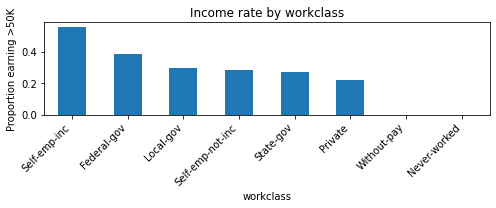

occupation
                   proportion_over_50k  count
Adm-clerical                  0.134483   3770
Armed-Forces                  0.111111      9
Craft-repair                  0.226641   4099
Exec-managerial               0.484014   4066
Farming-fishing               0.115694    994
Handlers-cleaners             0.062774   1370
Machine-op-inspct             0.124875   2002
Other-service                 0.041578   3295
Priv-house-serv               0.006711    149
Prof-specialty                0.449034   4140
Protective-serv               0.325116    649
Sales                         0.269315   3650
Tech-support                  0.304957    928
Transport-moving              0.200376   1597


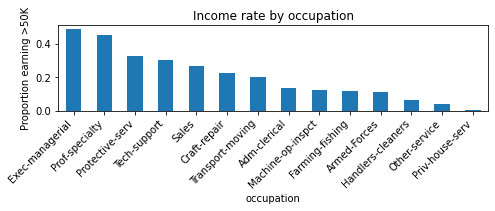

marital-status
                       proportion_over_50k  count
Divorced                          0.104209   4443
Married-AF-spouse                 0.434783     23
Married-civ-spouse                0.446848  14976
Married-spouse-absent             0.081340    418
Never-married                     0.045961  10683
Separated                         0.064390   1025
Widowed                           0.085599    993


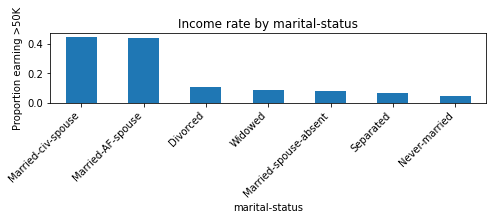

relationship
                proportion_over_50k  count
Husband                    0.448571  13193
Not-in-family              0.103070   8305
Other-relative             0.037717    981
Own-child                  0.013220   5068
Unmarried                  0.063262   3446
Wife                       0.475128   1568


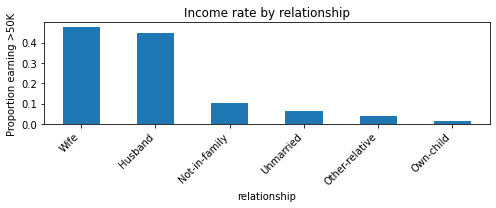

race
                    proportion_over_50k  count
Amer-Indian-Inuit              0.115756    311
Asian-Pac-Islander             0.265640   1039
Black                          0.123880   3124
Other                          0.092251    271
White                          0.255860  27816


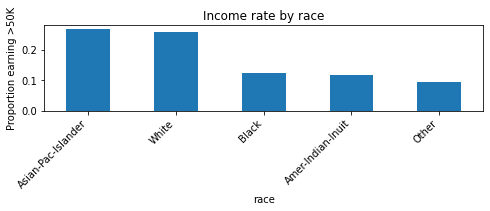

sex_selfID
            proportion_over_50k  count
sex_selfID                            
Non-Female             0.305737  21790
Female                 0.109461  10771


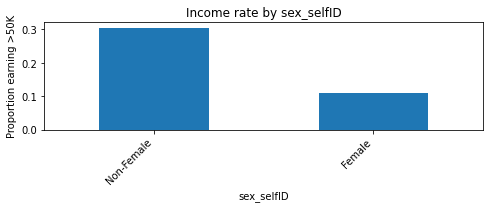

In [6]:
categorical_features = ['workclass', 'occupation', 'marital-status', 
                         'relationship', 'race', 'sex_selfID']

for col in categorical_features:
    rates = df.groupby(col)['income_binary'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    
    print(col)
    print(pd.DataFrame({'proportion_over_50k': rates, 'count': counts}))
    
    plt.figure(figsize=(7, 3))
    rates.plot(kind='bar')
    plt.ylabel('Proportion earning >50K')
    plt.title(f'Income rate by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

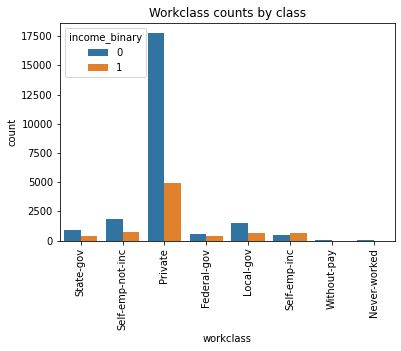

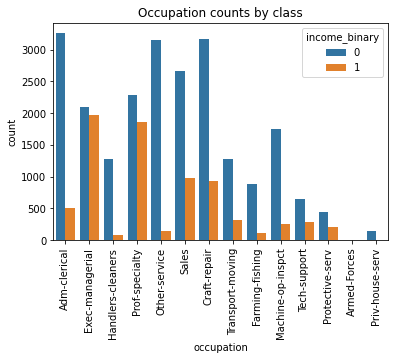

In [7]:
plt.figure()
sns.countplot(data=df, x='workclass', hue='income_binary')
plt.xticks(rotation=90)
plt.title('Workclass counts by class')
plt.show()

plt.figure()
sns.countplot(data=df, x='occupation', hue='income_binary')
plt.xticks(rotation=90)
plt.title('Occupation counts by class')
plt.show()

In [8]:
print(df['native-country'].value_counts())
print(df.groupby('native-country')['income_binary'].mean().sort_values(ascending=False))

United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                           29
France                      

In [9]:
for col in ['age', 'workclass', 'occupation', 'hours-per-week', 'native-country']:
    missing_flag = df[col].isnull()
    if missing_flag.sum() > 0:
        print(df.groupby(missing_flag)['income_binary'].mean())

age
False    0.240933
True     0.216049
Name: income_binary, dtype: float64
workclass
False    0.248983
True     0.104031
Name: income_binary, dtype: float64
occupation
False    0.249040
True     0.103635
Name: income_binary, dtype: float64
hours-per-week
False    0.240880
True     0.233846
Name: income_binary, dtype: float64
native-country
False    0.240634
True     0.250429
Name: income_binary, dtype: float64


In [10]:
print(df.describe())
print(df.isnull().sum())
print(df.info())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32399.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.589216  1.897784e+05      10.080679    615.907773     87.303830   
std       13.647862  1.055500e+05       2.572720   2420.191974    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  14084.000000   4356.000000   

       hours-per-week  income_binary  
count    32236.000000   32561.000000  
mean        40.450428       0.240810  
std         12.353748       0.427581  
min          1.000000       0.000000  
25%         40.000000       0.000000  
50%         40.000000       0.000000  
75%   

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Class imbalance: ~24% of individuals earn >50K, ~76% earn <=50K.

The histograms/boxplots show capital-gain and capital-loss are extremely right-skewed, and those outliers are disproportionately in the >50K class, which is why capital-gain shows up as a strong predictor despite most people having none. The >50K group skews somewhat older and works more hours on average.

Occupation shows the widest, most reliable spread.
Married-civ-spouse (44.7%) and Husband/Wife (44.9%/47.5%) are far more likely to earn >50K than Never-married (4.6%) or Own-child (1.3%). This likely reflects age/career-stage more than marriage itself causing income.
Workclass: Self-emp-inc at 55.7%, well above Private (21.9%).
Native-country: most extreme rates are single-digit sample sizes and not meaningful. The reliable comparison is really just US (24.6%) vs. "other" which might not be useful.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

The Census Income dataset was collected from the 1994 US Census, so it may reflect historical social and economic inequalities that existed at that time.
Because of these patterns, the model could unintentionally learn biased relationships and produce less accurate predictions for certain demographic groups.

Incorrect predictions could negatively affect people applying for financial assistance or lending programs. For example, if someone who actually earns more than 50K is predicted to earn less, or vice versa, they could be incorrectly prioritized or denied access to services.
Minority groups, women, immigrants, or individuals from historically disadvantaged communities may be at greater risk if the model reflects biases present in the training data.

This dataset is heavily skewed toward White (85%) and male-labeled (67%) individuals. Therefore, those features will not be used because the model has few examples to learn from.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
df['age'] = df['age'].fillna(df['age'].median())
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].median())
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [12]:
df = df.drop(columns=['fnlwgt', 'education', 'sex_selfID', 'race'])
df.columns.tolist()

['age',
 'workclass',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income_binary']

In [13]:
for col in ['capital-gain', 'capital-loss']:
    cap_value = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_value)

df[['capital-gain', 'capital-loss']].describe()

,capital-gain,capital-loss
count,32561.000000,32561.000000
mean,615.907773,83.800068
std,2420.191974,382.955091
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,14084.000000,1980.000000


In [14]:
top_countries = df['native-country'].value_counts().nlargest(5).index.tolist()
df['native-country'] = df['native-country'].where(
    df['native-country'].isin(top_countries), 'Other'
)
df['native-country'].value_counts()

United-States    29170
Other             1830
Mexico             643
Unknown            583
Philippines        198
Germany            137
Name: native-country, dtype: int64

In [15]:
categorical_cols = ['workclass', 'marital-status', 'occupation', 
                     'relationship', 'native-country']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.shape)
df.head()

(32561, 44)


,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native-country_Mexico,native-country_Other,native-country_Philippines,native-country_United-States,native-country_Unknown
0,39.0,13,2174,0,40.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,50.0,13,0,0,13.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,38.0,9,0,0,40.0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
3,53.0,7,0,0,40.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,28.0,13,0,0,40.0,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0


In [16]:
if df['income_binary'].dtype == 'object':
    df['income_binary'] = df['income_binary'].map({'<=50K': 0, '>50K': 1})
print(df['income_binary'].value_counts())
df.dtypes.value_counts()

0    24720
1     7841
Name: income_binary, dtype: int64


uint8      38
int64       4
float64     2
dtype: int64

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

For age and hours per week, median imputation works because it makes the model less impacted by outliers and because only a small percent of that data is missing.

For categorical data, 'Unknown' is treated as its own informative category because it is correlated with lower income rate.

fnlwgt: census sampling weight, not a real attribute of the person
education: redundant with education-num
sex_selfID, race: excluded per fairness/ethical decision. they're dropped to avoid the model directly encoding those disparities.

Cap outliers in capital-gain / capital-loss: were heavily right-skewed with extreme outliers

native-country: 39 categories, most with <100 observations, making their income rates unreliable. "Other" prevents noise.

One-hot encode remaining categorical features. Encoding the full df (before train/test split) here avoids category mismatches between train/test sets, since all dummy columns are created consistently across the whole dataset up front. drop_first=True avoids the dummy variable trap (relevant for Logistic Regression).

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [17]:
# Create labeled examples from the dataset
# YOUR CODE HERE
y = df['income_binary']
X = df.drop(columns=['income_binary'])
print(X.shape, y.shape)

(32561, 43) (32561,)


In [18]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(26048, 43) (6513, 43)
0    19793
1     6255
Name: income_binary, dtype: int64
0    4927
1    1586
Name: income_binary, dtype: int64


In [19]:
# Train, test and evaluate your model
# YOUR CODE HERE
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()
X_train_lr.loc[:, numeric_cols] = scaler.fit_transform(X_train_lr[numeric_cols])
X_test_lr.loc[:, numeric_cols] = scaler.transform(X_test_lr[numeric_cols])

In [20]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
model = LogisticRegression(max_iter=1000)
model.fit(X_train_lr, y_train)

y_pred = model.predict(X_test_lr)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred, average='binary')

print(baseline_accuracy)
print(baseline_f1)

0.8556732688469215
0.6666666666666665


In [21]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

start = time.time()
grid_search.fit(X_train_lr, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test_lr)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, average='binary')

print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")

print(f"\nImprovement over baseline:")
print(f"Accuracy: {baseline_accuracy:.4f} -> {final_accuracy:.4f}")
print(f"F1 Score: {baseline_f1:.4f} -> {final_f1:.4f}")

Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 score: 0.6779252892075768
Final Accuracy: 0.8113
Final F1 Score: 0.6838

Improvement over baseline:
Accuracy: 0.8557 -> 0.8113
F1 Score: 0.6667 -> 0.6838


Top 10 features increasing likelihood of >50K:
                              feature  coefficient
14  marital-status_Married-civ-spouse     1.986066
2                        capital-gain     0.806163
21         occupation_Exec-managerial     0.785698
1                       education-num     0.749592
37                  relationship_Wife     0.652248
28         occupation_Protective-serv     0.590456
27          occupation_Prof-specialty     0.584222
30            occupation_Tech-support     0.568680
4                      hours-per-week     0.429167
0                                 age     0.390625

Top 10 features decreasing likelihood of >50K:
                         feature  coefficient
36        relationship_Unmarried    -0.360958
5            workclass_Local-gov    -0.445921
16  marital-status_Never-married    -0.448123
10           workclass_State-gov    -0.457367
9     workclass_Self-emp-not-inc    -0.534863
34   relationship_Other-relative    -0.652903
25      occupation_Oth

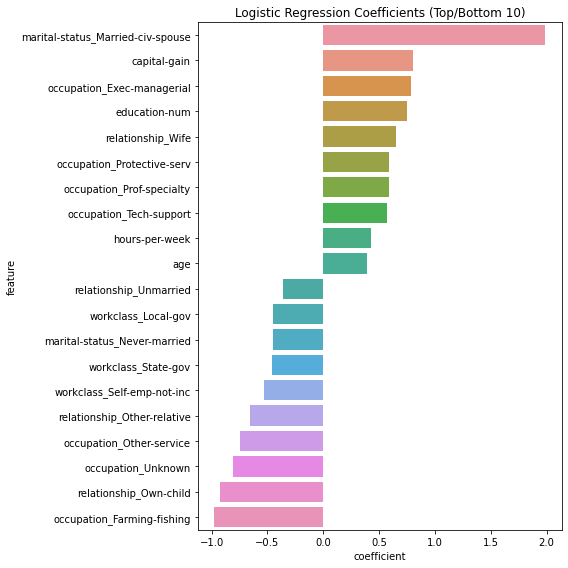

In [22]:
# Interpret your model's outputs 
# YOUR CODE HERE
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top 10 features increasing likelihood of >50K:")
print(coef_df.head(10))

print("\nTop 10 features decreasing likelihood of >50K:")
print(coef_df.tail(10))

plt.figure(figsize=(8, 8))
top_features = pd.concat([coef_df.head(10), coef_df.tail(10)])
sns.barplot(data=top_features, x='coefficient', y='feature')
plt.title('Logistic Regression Coefficients (Top/Bottom 10)')
plt.tight_layout()
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

I chose logistic regression because this is a binary classification problem. The features were a mix of numeric and one-hot-encoded categorical ones, and logistic regression is good at handling that combination. There were many relationships between the features and income rate which is also good for linear regressions. In a lending or financial assistance context, logisitc regression is good because it can explain why a prediction was made and isn't just a black box.

Grid search results: best params were C=1, penalty='l1', solver='liblinear.' These are close to sklearn's defaults (C=1.0, l2). Tuning didn't improve test performance. Baseline F1 (0.6667) vs. tuned F1 (0.6660) shows this. Accuracy (0.856) is much higher than F1 (0.667), which is expected given the class imbalance. The model is more confident on the majority class. Perhaps different features would make this better. 

Strongest positive predictors:
marital-status_Married-civ-spouse (~1.99) and Married-AF-spouse (~1.91).

Strongest negative predictors:
occupation_Priv-house-serv (-1.76) and occupation_Unknown (-1.06), also relationship_Own-child (-1.04) and occupation_Farming-fishing (-0.97).

The model is picking up household/family structure as one of the strongest signals. Marital and relationship status outweigh education-num and capital-gain combined. Since coefficients on dummy variables are relative to the dropped reference category, interpret each as "compared to the baseline category" rather than in isolation.

I deliberately dropped race and sex_selfID after EDA showed large income-rate gaps and underrepresentation by these groups, but for example, "Wife" as a relationship category is tied to sex_selfID). This is a design flaw.
These income-rate gaps and family-structure patterns reflect labor-market and social norms of 1994, not necessarily present-day. A model trained on this data risks reproducing inequities.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [23]:
# Scale your data for the neural network

# Create the scaler
scaler_nn = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler_nn.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler_nn.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [ ]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# YOUR CODE HERE
# Decision: 2 hidden layers, 64 units then 32 units, ReLU activation.
# Rationale: 64 units gives the network enough capacity to combine 43 input 
# features into useful representations without being excessive for a dataset 
# of this size (about 26k training rows). Narrowing to 32 in the second layer 
# funnels toward the binary decision. ReLU is the standard choice 
# for hidden layers.
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                2816      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 4,929
Trainable params: 4,929
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [ ]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# Decision: learning rate = 0.01
# Rationale: a common starting point for SGD. high enough to make 
# meaningful progress each step, low enough to avoid diverging.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [ ]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [ ]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [ ]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

# Decision: 100 epochs.
# Rationale: gives the model enough passes over the data to converge given 
# the moderate learning rate, while keeping runtime reasonable on approx 21k 
# training rows (after the 0.2 validation split).
num_epochs = 100

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
    verbose=0
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.3113, Accuracy: 0.8530, Val_loss: 0.3147, Val_accuracy: 0.8549


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



In [ ]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [ ]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
nn_pred_probs = nn_model.predict(X_test_scaled)
nn_pred_labels = (nn_pred_probs >= 0.5).astype(int)

In [ ]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE

nn_accuracy = accuracy_score(y_test, nn_pred_labels)
nn_f1 = f1_score(y_test, nn_pred_labels, average='binary')

print(f"Neural Network Accuracy: {nn_accuracy:.4f}")
print(f"Neural Network F1 Score: {nn_f1:.4f}")

#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

Despite the overfitting signal, the model still generalized reasonably well (test accuracy 0.8572 is close to the 0.86 validation range, not wildly worse), so 64-->32 units with ReLU was reasonable capacity for 43 input features, even if epoch count ran a bit long.
Clearly there was some overfitting after epoch 40-50. Training for 100 epochs was more than necessary, validation loss/accuracy essentially plateaus by around epoch 15-20.
The fact that test accuracy (0.8572) came in close to the best validation accuracy (0.861) rather than close to the inflated training accuracy (0.8717) is reassuring. Overfitting didn't badly damage real-world generalization. 

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [ ]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [final_accuracy, final_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))
#
# YOUR CODE HERE

### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Neural network wins on both metrics, but by a modest amount. F1 improved more than accuracy, meaning the NN's edge is concentrated in handling the minority (>50K) class better. Neither metric got worse.
2. NN took ~265 seconds to train vs for logistic regression it trained almost instantly. Also, the NN required architecture decisions like layer count, units, learning rate, and epochs that logistic regression doesn't need. I also saw overfitting, and the coefficients aren't directly interpretable the way LR's are. It was only a small F1 gain relative to the complexity added, so I don't think a 1.3-point F1 gain is worth losing interpretability and adding training time.
3. A CDFI making lending decisions likely needs to explain why an applicant was scored a certain way, both for documentation and potentially legal/ethical reasons. Only logistic regression coefficients support this. A false positive costs this client more because EquiLend would be spending money in the wrong places, so precision matters. I would recommend deploying logistic regression as the primary model for its interpretability and speed, given the NN's performance doesn't clearly justify losing explainability in a context where we're making decisions on lending or providing services.
4. Next, I would address overfitting directly: re-run the NN with early stopping and see if test F1 improves. I would try engineering an explicit is_missing flag as its own feature rather than relying on the Unknown category alone. I would try a Decision Tree as a third comparison point. Trees handle non-linear relationships and categorical splits differently than both models I tried so far.


---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I specifically used Claude for ideas on data exploration, and then throughout the assignment to brainstormethical considerations and business applications. There was some code with plotting and printing results that I wanted formatted neatly and I found that Claude was helpful for this.
2. Thinking about what features to use and what to do with them was something I had to think about myself. I worked through it myself first and explored the data by printing basic things like the data types and counts and column names, but then to find out which features were actually worthy I used Claude and looked at the numbers myself then asked Claude if I was missing anything. I did this for the data exploration: "I'm working on a machine learning lab in a Jupyter notebook using Python, pandas, and seaborn/matplotlib.
Right now I'm working on: exploring my dataset's features before choosing a model. I have a binary classification problem (predicting income >50K vs ≤50K) with both numeric features (age, education-num, capital-gain, capital-loss, hours-per-week) and categorical features (workclass, occupation, marital-status, relationship, race, sex_selfID, native-country).
Here's what I've tried so far: I made a pairplot of my numeric features colored by income class, and countplots of workclass and occupation split by income class.
Here's where I'm getting stuck: I'm not sure if these plots actually tell me what I need to know. My workclass/occupation countplots show raw counts, but categories like 'Private' have way more people than 'Without-pay,' so I'm not sure if I'm actually seeing a meaningful pattern or just seeing sample size differences. I also haven't looked at my other categorical features at all yet, and I'm not sure how to check whether a feature like sex_selfID or race is worth including given fairness concerns.
I want to understand what I'm doing, so please don't give me the full solution. Instead, guide me with questions, hints, and explanations. Help me think through what's missing from my analysis and what technique would actually answer my question, rather than just handing me code."
3. I verified my work was correct by reading it and understanding the plot inputs and then running it to see that it makes sense.
4. Next time, I think I would still use AI in the same way, but I really need to give myself time to struggle through articulating my thoughts on my own so I can think about the written portions myself and come up with unique thoughts that dont require me to brainstorm with claude.

Please note numbers are outdated and analysis matches a previous run that I did not get the chance to analyze after noticing a bug where my values were not scaled correctly.